<a href="https://colab.research.google.com/github/Disha-pro/rice-grain-classification-end-to-end-ml-pipeline/blob/main/Grain_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np

rice = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/Rice_Cammeo_Osmancik.csv")



grain_project.**py**

 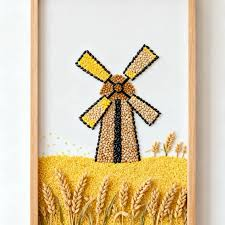

In [6]:
rice.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,Cammeo
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,Cammeo
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,Cammeo
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,Cammeo
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,Cammeo


In [7]:
rice.tail()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
3805,11441,415.858002,170.486771,85.756592,0.864280,11628,0.681012,Osmancik
3806,11625,421.390015,167.714798,89.462570,0.845850,11904,0.694279,Osmancik
3807,12437,442.498993,183.572922,86.801979,0.881144,12645,0.626739,Osmancik
3808,9882,392.296997,161.193985,78.210480,0.874406,10097,0.659064,Osmancik
3809,11434,404.709991,161.079269,90.868195,0.825692,11591,0.802949,Osmancik


In [8]:
rice.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   int64  
 1   Perimeter          3810 non-null   float64
 2   Major_Axis_Length  3810 non-null   float64
 3   Minor_Axis_Length  3810 non-null   float64
 4   Eccentricity       3810 non-null   float64
 5   Convex_Area        3810 non-null   int64  
 6   Extent             3810 non-null   float64
 7   Class              3810 non-null   object 
dtypes: float64(5), int64(2), object(1)
memory usage: 238.3+ KB


In [9]:
rice.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000
mean,12667.727559,454.239180,188.776222,86.313750,0.886871,12952.496850,0.661934
std,1732.367706,35.597081,17.448679,5.729817,0.020818,1776.972042,0.077239
min,7551.000000,359.100006,145.264465,59.532406,0.777233,7723.000000,0.497413
25%,11370.500000,426.144753,174.353855,82.731695,0.872402,11626.250000,0.598862
50%,12421.500000,448.852493,185.810059,86.434647,0.889050,12706.500000,0.645361
75%,13950.000000,483.683746,203.550438,90.143677,0.902588,14284.000000,0.726562
max,18913.000000,548.445984,239.010498,107.542450,0.948007,19099.000000,0.861050


In [10]:
rice.isnull().sum()

,0
Area,0
Perimeter,0
Major_Axis_Length,0
Minor_Axis_Length,0
Eccentricity,0
Convex_Area,0
Extent,0
Class,0


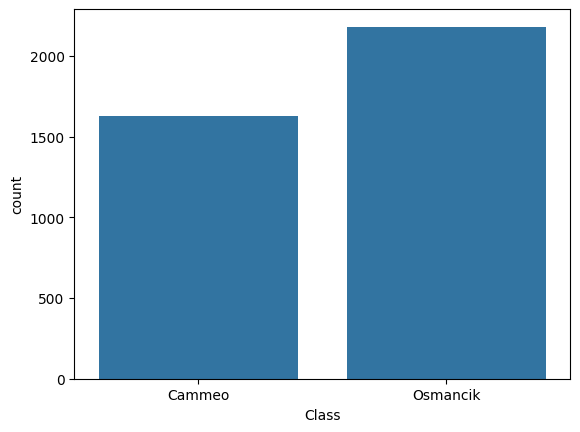

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=rice)
plt.show()

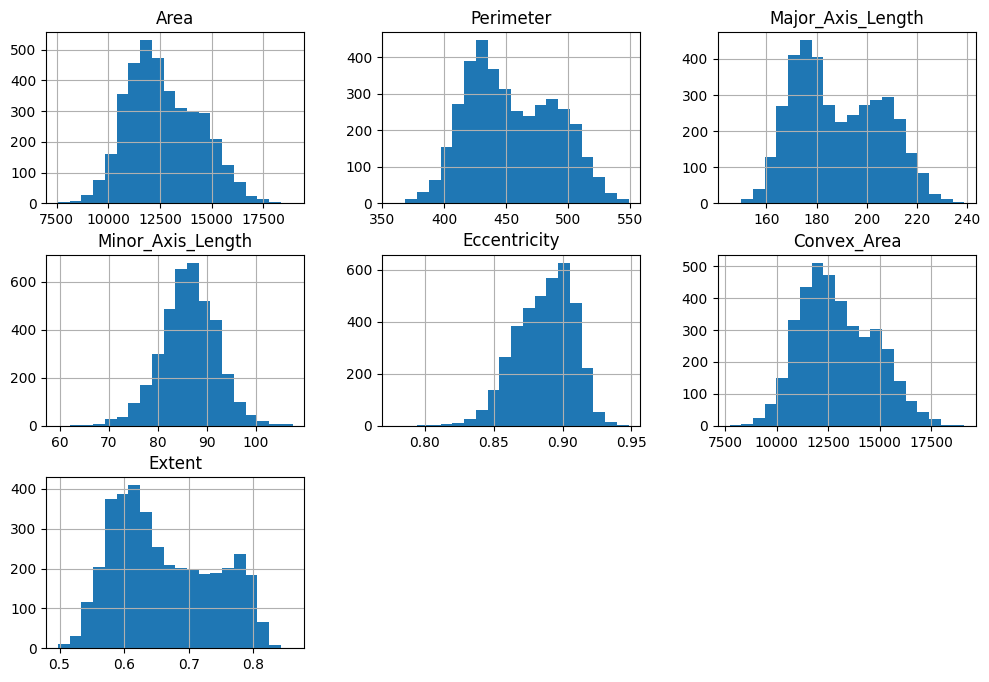

In [12]:
import matplotlib.pyplot as plt

rice.hist(figsize=(12,8), bins=20)
plt.show()

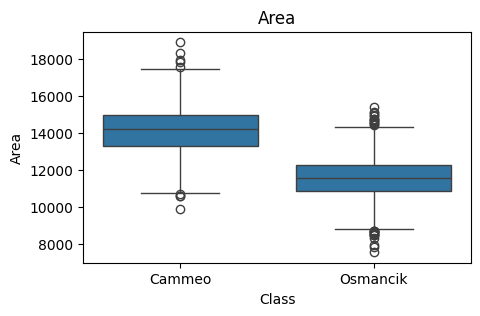

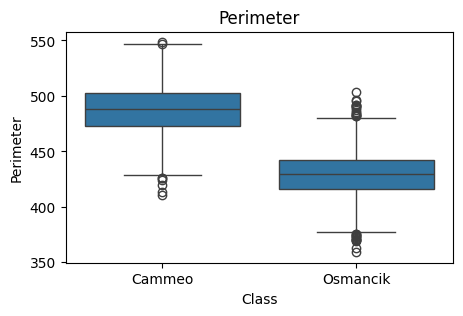

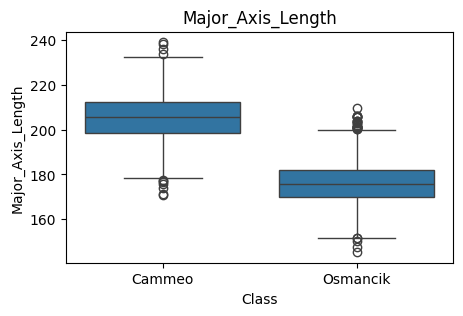

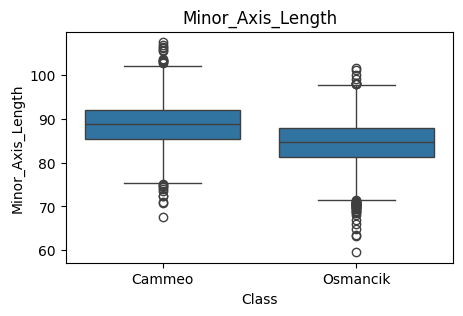

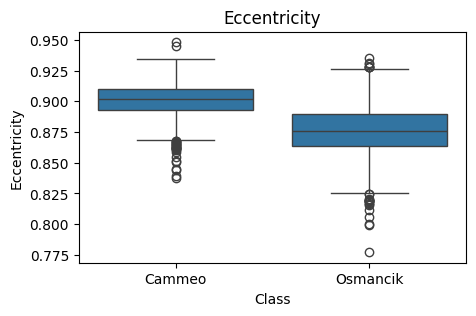

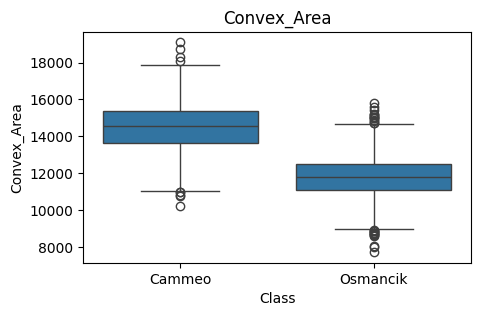

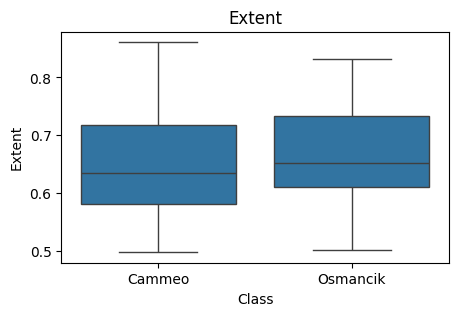

In [13]:
for col in rice.columns[:-1]:
    plt.figure(figsize=(5,3))
    sns.boxplot(x='Class', y=col, data=rice)
    plt.title(col)
    plt.show()

**'''Why are we doing this?**

Your Class column has text values: "Cammeo" and "Osmancik". Every ML algorithm works on numbers, not strings. Before we can train any model, the target must be converted to 0 and 1. This is called Label Encoding.

**How does this add impact to your project?**

This is the bridge between raw data and model-ready data. Without this, sklearn will throw errors. '''

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# LabelEncoder → a sklearn tool that converts text categories to numbers

rice['Class_encoded'] = le.fit_transform(rice['Class'])
# fit_transform → first LEARNS what classes exist (fit), then CONVERTS them (transform)
# Cammeo → 0, Osmancik → 1  (alphabetical order by default)

print(le.classes_)
#shows you which label got which number - always verify this!

print(rice[['Class','Class_encoded']].head(10))


['Cammeo' 'Osmancik']
    Class  Class_encoded
0  Cammeo              0
1  Cammeo              0
2  Cammeo              0
3  Cammeo              0
4  Cammeo              0
5  Cammeo              0
6  Cammeo              0
7  Cammeo              0
8  Cammeo              0
9  Cammeo              0


**'''Why are we doing this?**

A heatmap shows how strongly each feature relates to every other feature. If two features are highly correlated (say 0.95), they carry almost the same information — keeping both is redundant and can confuse the model. This is called multicollinearity.

**How does this add impact to your project?**

This step directly drives feature selection in the next step. '''

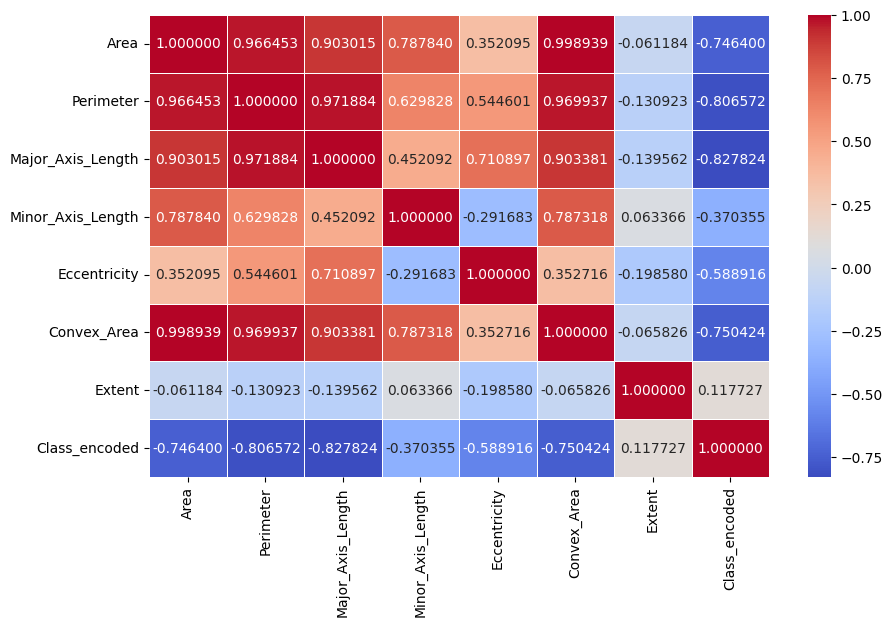

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
# Sets the canvas size — larger figure = easier to read heatmap

corr_matrix = rice.drop(columns=['Class']).corr()
# .drop(columns=['Class']) → removes text column, can't correlate text
# .corr() → calculates Pearson correlation (-1 to +1) between all numerical columns


sns.heatmap(corr_matrix,
            annot=True,  #print actaul no. inside cell
            fmt='2f',      #format numbers to 2 decimal places
            cmap='coolwarm',  #color schme
            linewidths=0.5) #thin lines between cells for reafbaility
plt.show()

**'''Why are we doing this?**

Area and Convex_Area have 0.999 correlation — they are essentially the same measurement. Feeding both into a model is like giving it the same information twice. It wastes computation, can cause multicollinearity, and makes your model harder to interpret. We drop the weaker/less meaningful one.

**How does this add impact to your project?**

Feature selection is a conscious engineering decision. '''

In [19]:
# We drop Convex_Area because Area already captures the same info
# Convex_Area = smallest convex shape around the grain ≈ almost identical to Area

features_to_drop =['Convex_Area','Class','Class_encoded']
# Convex_Area → redundant (0.999 corr with Area)
# Class → original text column, we already have Class_encoded

X = rice.drop(columns = features_to_drop)
y = rice['Class_encoded']
# y → your TARGET (what the model is trying to predict)
# Class_encoded has 0 (Cammeo) and 1 (Osmancik)

print("Feature columns: ", X.columns.tolist())
# Confirm which features survived — should be 6 columns

print("X shape: ",X.shape) #(rows.col)

print("Y shape: ",y.shape) #one label per row

Feature columns:  ['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length', 'Eccentricity', 'Extent']
X shape:  (3810, 6)
Y shape:  (3810,)


**#Train-Test_SPlit**

**'''Why are we doing this?**

You cannot test your model on the same data it learned from —
that's like giving students the exam answers during study time.
The split creates a training set (model learns here) and a test
set (model is evaluated here — data it has never seen).
This gives you an honest measure of real-world performance.'''

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                 test_size=0.2,     # 20% goes to test → 80% trains the model
                                                                     # 3810 rows → ~3048 train, ~762 test
                                                 random_state=42,  # fixes the randomness — same split every run
                                                                  # 42 is convention, any number works
                                                 stratify = y)   # ensures BOTH splits have same % of Cammeo/Osmancik
                                                                 # without this, split could be unbalanced by chance

print("Train size: ",X_train.shape)
print("Test size: ",X_test.shape)

# Verify class balance is maintained after split
print("\nTrain class distribution:\n", y_train.value_counts())
print("\nTest class distribution:\n", y_test.value_counts())


Train size:  (3048, 6)
Test size:  (762, 6)

Train class distribution:
 Class_encoded
1    1744
0    1304
Name: count, dtype: int64

Test class distribution:
 Class_encoded
1    436
0    326
Name: count, dtype: int64


**Feature Scaling**

'**''Why are we doing this?**

Look at your feature ranges right now:

Area → values around 10,000–18,000
Eccentricity → values around 0.78–0.95
Extent → values around 0.5–0.86

These are on completely different scales. Algorithms like Logistic Regression calculate distances and weights — if Area is 15,000 and Eccentricity is 0.88, the model will wrongly assume Area matters 15,000x more just because its number is bigger. Scaling fixes this by bringing everyone to the same playing field.

**How does this add impact to your project? **

Scaling is what separates a careful ML practitioner from someone who just copy-pastes code. It directly improves model accuracy and convergence speed. '''

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# StandardScaler → transforms each feature so that:
# mean becomes 0, standard deviation becomes 1
# Formula: z = (value - mean) / std_deviation
# This is called "Z-score normalization"

X_train_scaled = scaler.fit_transform(X_train)
# fit_transform on TRAIN only:
# fit → scaler LEARNS the mean and std FROM training data
# transform → applies the formula to training data
# WHY only train? Because in real world, you don't have test data yet

X_test_scaled = scaler.transform(X_test)
# transform ONLY on test (no fit!)
# Uses the SAME mean/std learned from training data
# If you fit on test too → data leakage again!

print("first row before scaling: ",X_train.iloc[0].values)
print("First row after scaling: ",X_train_scaled[0])
# You'll see large numbers become small decimals around 0

first row before scaling:  [1.30780000e+04 4.52990997e+02 1.83978973e+02 9.16900101e+01
 8.66963208e-01 7.32743144e-01]
First row after scaling:  [ 0.23094218 -0.03876    -0.27319185  0.92664268 -0.93342026  0.90972741]


#First MOdel = Logistic Regression
#Logistic Regression is your baseline model. In every serious ML project, you always start simple before going complex. It's fast, interpretable, and gives you a benchmark number. If your fancy model later can't beat this, something is wrong with the complex model.

Logistic Regression Accuracy: 0.9146981627296588

Classification Report:
               precision    recall  f1-score   support

      Cammeo       0.91      0.89      0.90       326
    Osmancik       0.92      0.94      0.93       436

    accuracy                           0.91       762
   macro avg       0.91      0.91      0.91       762
weighted avg       0.91      0.91      0.91       762



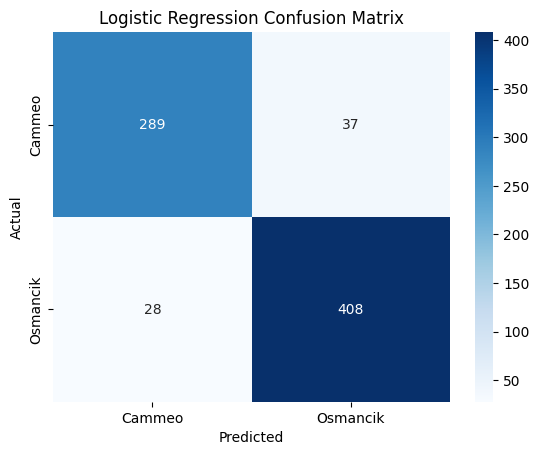

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#---------------TRAIN
lr_model = LogisticRegression(random_state =42,
                              max_iter = 1000)
# LogisticRegression → despite the name, it's a CLASSIFICATION algorithm
# random_state=42 → reproducibility
# max_iter=1000 → max steps the solver gets to find best weights
#                  default is 100, rice dataset needs more iterations

lr_model.fit(X_train_scaled,y_train)
# fit → the model LEARNS from training data
# It finds the best decision boundary between Cammeo and Osmancik

#__________________PREDICT

y_pred_lr = lr_model.predict(X_test_scaled)

#-----------------EVALUATE
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
# accuracy_score → % of correct predictions out of total

print("\nClassification Report:\n", classification_report(y_test, y_pred_lr,target_names=['Cammeo','Osmancik']))
# classification_report → shows Precision, Recall, F1 for EACH class
# Precision → of all predicted Cammeo, how many were actually Cammeo?
# Recall → of all actual Cammeo, how many did we correctly catch?
# F1 → harmonic mean of Precision and Recall (balanced metric)

#-------------CONFUSION MATRIX
cm = confusion_matrix(y_test,y_pred_lr)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Cammeo','Osmancik'],
            yticklabels=['Cammeo','Osmancik'])
# fmt='d' → display as integers not decimals
# Each cell shows: how many predictions fell into that category

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Train Random Forest Model**

**Why are we doing this?**

Logistic Regression draws one straight line to separate classes. Random Forest builds 100 decision trees, each trained on a random subset of data, then takes a majority vote. It handles non-linear relationships and is far more powerful. Think of it as 100 experts voting vs 1 expert deciding alone.
How does this add impact to your project?

This is where your project moves from basic to impressive. Comparing models side-by-side is a hallmark of a proper ML pipeline. Random Forest also gives you feature importance — which feature mattered most — which is incredibly powerful for business storytelling  

Random Forest Accuracy: 0.9199475065616798

Classification Report:
               precision    recall  f1-score   support

      Cammeo       0.93      0.88      0.90       326
    Osmancik       0.92      0.95      0.93       436

    accuracy                           0.92       762
   macro avg       0.92      0.92      0.92       762
weighted avg       0.92      0.92      0.92       762



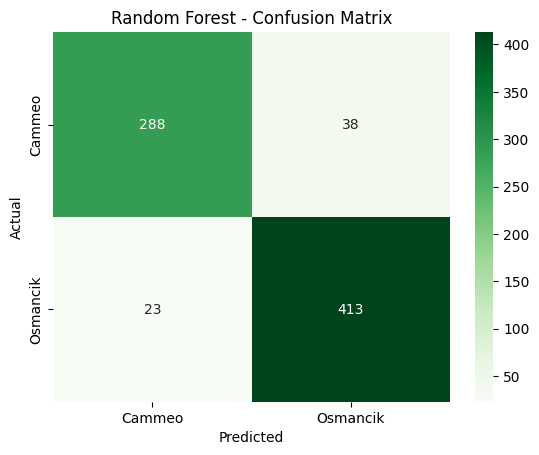


Feature Importances:
              Feature  Importance
2  Major_Axis_Length    0.313732
1          Perimeter    0.295688
0               Area    0.183746
4       Eccentricity    0.118397
3  Minor_Axis_Length    0.051703
5             Extent    0.036734


/tmp/ipykernel_16161/408218816.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


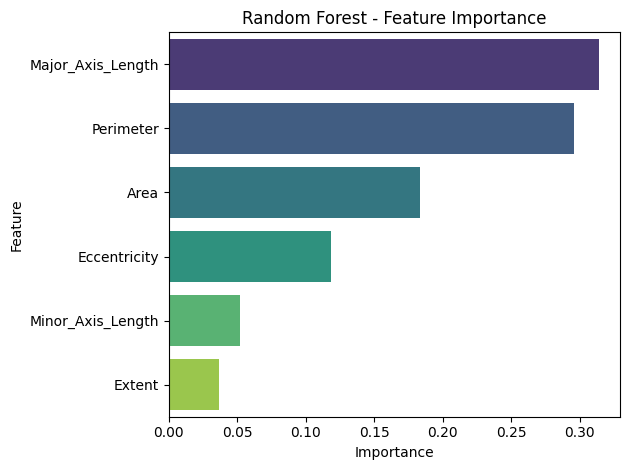

In [29]:
from sklearn.ensemble import RandomForestClassifier

# --- TRAIN ---
rf_model = RandomForestClassifier(
    n_estimators=100,     # build 100 decision trees
                          # more trees = more stable, but slower
    random_state=42,      # reproducibility — same trees every run
    max_depth=None        # trees grow until leaves are pure
                          # None means no restriction on depth
)

rf_model.fit(X_train_scaled, y_train)
# fit → all 100 trees learn from different random subsets of training data
# This randomness is what makes it robust — no single tree overfits

# --- PREDICT ---
y_pred_rf = rf_model.predict(X_test_scaled)

# --- EVALUATE ---
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf,
      target_names=['Cammeo', 'Osmancik']))

# --- CONFUSION MATRIX ---
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Cammeo','Osmancik'],
            yticklabels=['Cammeo','Osmancik'])
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- FEATURE IMPORTANCE --- (Random Forest's superpower)
importances = rf_model.feature_importances_
# feature_importances_ → how much each feature contributed to decisions
# values sum to 1.0 (like percentages)

feature_names = X_train.columns
# X_train.columns → the 6 feature names in order

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)
# sort_values → rank from most to least important

print("\nFeature Importances:\n", feat_imp_df)

# Plot it
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Random Forest - Feature Importance')
plt.tight_layout()
plt.show()

**Why are we doing this?**

You now have two trained models. Keeping results in your head is not professional — you need a structured comparison that tells a clear story. Which model wins? By how much? This is your decision-making artifact.

In [30]:
from sklearn.metrics import f1_score

# Build a clean comparison dataframe
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),   # LR accuracy you already have
        accuracy_score(y_test, y_pred_rf)    # RF accuracy just calculated
    ],

    'F1_Cammeo': [
        f1_score(y_test, y_pred_lr, pos_label=0),   # pos_label=0 → Cammeo
        f1_score(y_test, y_pred_rf, pos_label=0)
    ],

    'F1_Osmancik': [
        f1_score(y_test, y_pred_lr, pos_label=1),   # pos_label=1 → Osmancik
        f1_score(y_test, y_pred_rf, pos_label=1)
    ]
})

# Round for clean display
results[['Accuracy','F1_Cammeo','F1_Osmancik']] = \
    results[['Accuracy','F1_Cammeo','F1_Osmancik']].round(4)
# .round(4) → 4 decimal places, clean and readable

print(results.to_string(index=False))
# to_string(index=False) → prints without row numbers, looks like a report

              Model  Accuracy  F1_Cammeo  F1_Osmancik
Logistic Regression    0.9147     0.8989       0.9262
      Random Forest    0.9199     0.9042       0.9312


Gradient Boosting Accuracy: 0.9133858267716536

Classification Report:
               precision    recall  f1-score   support

      Cammeo       0.91      0.88      0.90       326
    Osmancik       0.91      0.94      0.93       436

    accuracy                           0.91       762
   macro avg       0.91      0.91      0.91       762
weighted avg       0.91      0.91      0.91       762



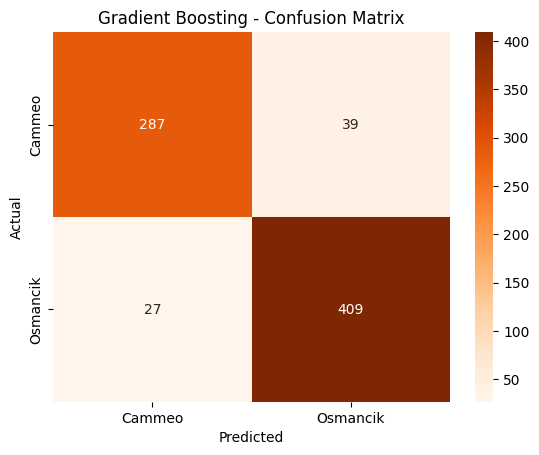


--- FINAL MODEL COMPARISON ---
              Model  Accuracy  F1_Cammeo  F1_Osmancik
Logistic Regression    0.9147     0.8989       0.9262
      Random Forest    0.9199     0.9042       0.9312
  Gradient Boosting    0.9134     0.8969       0.9253


In [31]:
from sklearn.ensemble import GradientBoostingClassifier

# --- TRAIN ---
gb_model = GradientBoostingClassifier(
    n_estimators=100,     # 100 trees built sequentially
                          # each tree corrects errors of previous one
    learning_rate=0.1,    # how much each tree contributes to final answer
                          # lower = more careful learning, less overfitting
                          # 0.1 is the standard starting value
    max_depth=3,          # each individual tree is kept shallow (depth 3)
                          # shallow trees = weak learners that combine well
    random_state=42       # reproducibility
)

gb_model.fit(X_train_scaled, y_train)
# fit → trees are built one by one, each fixing the last one's mistakes

# --- PREDICT ---
y_pred_gb = gb_model.predict(X_test_scaled)

# --- EVALUATE ---
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb,
      target_names=['Cammeo', 'Osmancik']))

# --- CONFUSION MATRIX ---
cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Cammeo','Osmancik'],
            yticklabels=['Cammeo','Osmancik'])
plt.title('Gradient Boosting - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- UPDATE COMPARISON TABLE ---
results_final = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    'F1_Cammeo': [
        f1_score(y_test, y_pred_lr, pos_label=0),
        f1_score(y_test, y_pred_rf, pos_label=0),
        f1_score(y_test, y_pred_gb, pos_label=0)
    ],
    'F1_Osmancik': [
        f1_score(y_test, y_pred_lr, pos_label=1),
        f1_score(y_test, y_pred_rf, pos_label=1),
        f1_score(y_test, y_pred_gb, pos_label=1)
    ]
})

results_final[['Accuracy','F1_Cammeo','F1_Osmancik']] = \
    results_final[['Accuracy','F1_Cammeo','F1_Osmancik']].round(4)

print("\n--- FINAL MODEL COMPARISON ---")
print(results_final.to_string(index=False))

**ROC-AUC Curve**
*Why are we doing this?*

Accuracy alone can be misleading — what if your model is just guessing the majority class? The ROC curve plots True Positive Rate vs False Positive Rate at every possible threshold. The AUC (Area Under Curve) gives a single number: 1.0 = perfect model, 0.5 = random guessing. It's a threshold-independent measure of model quality.

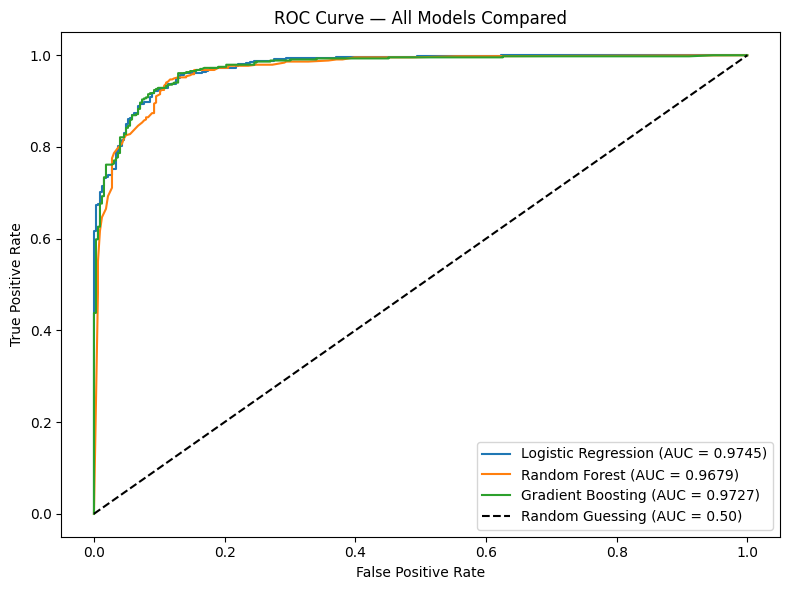

LR AUC:  0.9745
RF AUC:  0.9679
GB AUC:  0.9727


In [33]:
from sklearn.metrics import roc_curve, roc_auc_score

# predict_proba gives PROBABILITY of each class (not just 0 or 1)
# [:, 1] takes the probability of being class 1 (Osmancik)
# ROC curve needs probabilities, not hard predictions

lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]
gb_probs = gb_model.predict_proba(X_test_scaled)[:, 1]

# roc_curve returns 3 arrays:
# fpr = False Positive Rate (x-axis)
# tpr = True Positive Rate / Recall (y-axis)
# thresholds = the cutoff values used (we don't plot this)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_probs)

# AUC = single number summarising the curve
auc_lr = roc_auc_score(y_test, lr_probs)
auc_rf = roc_auc_score(y_test, rf_probs)
auc_gb = roc_auc_score(y_test, gb_probs)

# --- PLOT ALL 3 CURVES TOGETHER ---
plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.4f})')

plt.plot([0,1], [0,1], 'k--', label='Random Guessing (AUC = 0.50)')
# k-- → black dashed line → this is the "coin flip" baseline
# Any model above this line is better than random

plt.xlabel('False Positive Rate')   # X axis: how often we wrongly say Osmancik
plt.ylabel('True Positive Rate')    # Y axis: how often we correctly catch Osmancik
plt.title('ROC Curve — All Models Compared')
plt.legend(loc='lower right')       # legend in bottom right, away from the curves
plt.tight_layout()
plt.show()

print(f"LR AUC:  {auc_lr:.4f}")
print(f"RF AUC:  {auc_rf:.4f}")
print(f"GB AUC:  {auc_gb:.4f}")

Random Forest wins on raw accuracy but Logistic Regression wins on AUC. This tells you the dataset is linearly separable enough that a simple model competes with complex ones. That's a business insight — you don't always need the most expensive/complex model. Random Forest is your final chosen model because it wins the metric that matters most for deployment: overall correct predictions.

**Cross Validation (Prove Your Model is Trustworthy)**

*Why are we doing this?*

Your current accuracy is based on one specific 80/20 split. What if that split was lucky? Cross Validation splits your data 5 different ways, trains and tests 5 times, and averages the scores. This proves your model performs consistently — not just on one lucky split.

CV Scores (each fold): [0.9344 0.937  0.9173 0.9265 0.8845]
Mean CV Accuracy: 0.9199
Standard Deviation: 0.019


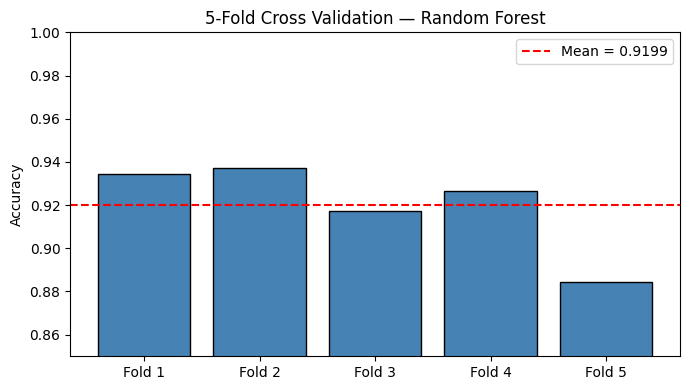

In [34]:
from sklearn.model_selection import cross_val_score

# Cross validation on Random Forest (our best model)
cv_scores = cross_val_score(
    rf_model,          # the model to evaluate
    X,                 # ALL features (not just train) — CV handles splitting itself
    y,                 # ALL labels
    cv=5,              # 5-fold: splits data into 5 parts
                       # trains on 4 parts, tests on 1, rotates 5 times
    scoring='accuracy' # metric to compute each round
)

print("CV Scores (each fold):", cv_scores.round(4))
# 5 individual accuracy scores — one per fold

print("Mean CV Accuracy:", cv_scores.mean().round(4))
# Average across all 5 folds — this is your TRUE model accuracy

print("Standard Deviation:", cv_scores.std().round(4))
# Low std = model is CONSISTENT across different data splits
# High std = model is unstable — depends too much on which data it sees

# Visual: bar chart of fold scores
plt.figure(figsize=(7, 4))
plt.bar(
    [f'Fold {i+1}' for i in range(5)],  # x-axis labels: Fold 1 to Fold 5
    cv_scores,                            # height of each bar
    color='steelblue',
    edgecolor='black'
)
plt.axhline(
    y=cv_scores.mean(),                  # draws a horizontal line at mean
    color='red',
    linestyle='--',
    label=f'Mean = {cv_scores.mean():.4f}'
)
plt.title('5-Fold Cross Validation — Random Forest')
plt.ylabel('Accuracy')
plt.ylim(0.85, 1.0)                      # zoom y-axis so differences are visible
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
import joblib
import os

# Create a folder to store model files — clean project structure
os.makedirs('models', exist_ok=True)
# os.makedirs → creates the folder if it doesn't exist
# exist_ok=True → won't throw error if folder already exists

# Save the trained Random Forest model
joblib.dump(rf_model, 'models/random_forest_rice.pkl')
# joblib.dump → serialises (converts) Python object into a binary file
# rf_model → the trained model object with all 100 trees inside
# .pkl → pickle format, standard for saving sklearn models

# Save the scaler too — CRITICAL!
joblib.dump(scaler, 'models/scaler_rice.pkl')
# WHY save scaler? When someone gives new grain data to predict,
# you MUST scale it the same way training data was scaled
# Without saved scaler → predictions will be completely wrong

print("✅ Model saved successfully!")

# --- VERIFY: Load it back and test ---
loaded_model = joblib.load('models/random_forest_rice.pkl')
loaded_scaler = joblib.load('models/scaler_rice.pkl')

# Test with one real sample from test set
sample = X_test.iloc[[0]]               # take first row of test data
                                         # double brackets [[0]] keeps it as DataFrame
sample_scaled = loaded_scaler.transform(sample)   # scale it properly
prediction = loaded_model.predict(sample_scaled)  # predict

# Convert numeric prediction back to class name
class_names = {0: 'Cammeo', 1: 'Osmancik'}
print(f"Sample prediction: {class_names[prediction[0]]}")
print(f"Actual label:      {class_names[y_test.iloc[0]]}")
# If these match → model saved and loaded perfectly

✅ Model saved successfully!
Sample prediction: Cammeo
Actual label:      Cammeo
